### Problem statement: The objective of this project is to group wines into meaningful clusters based on their chemical characteristics using the K-Means clustering algorithm, without using predefined wine labels.

### Import necessory libraries and understand dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize']=(10,5)
plt.rcParams['figure.dpi']=150
sns.set_theme(style='darkgrid', palette='viridis')

In [2]:
df=pd.read_csv(r"C:\Users\dssas\OneDrive\Desktop\DS\Dataset\Wine Quality Clustering.csv")
df.head()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


### Understand the dataset

In [3]:
df.shape

(178, 13)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Alcohol               178 non-null    float64
 1   Malic_Acid            178 non-null    float64
 2   Ash                   178 non-null    float64
 3   Ash_Alcanity          178 non-null    float64
 4   Magnesium             178 non-null    int64  
 5   Total_Phenols         178 non-null    float64
 6   Flavanoids            178 non-null    float64
 7   Nonflavanoid_Phenols  178 non-null    float64
 8   Proanthocyanins       178 non-null    float64
 9   Color_Intensity       178 non-null    float64
 10  Hue                   178 non-null    float64
 11  OD280                 178 non-null    float64
 12  Proline               178 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 18.2 KB


In [5]:
df.describe()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [6]:
df.dtypes

Alcohol                 float64
Malic_Acid              float64
Ash                     float64
Ash_Alcanity            float64
Magnesium                 int64
Total_Phenols           float64
Flavanoids              float64
Nonflavanoid_Phenols    float64
Proanthocyanins         float64
Color_Intensity         float64
Hue                     float64
OD280                   float64
Proline                   int64
dtype: object

### EDA

In [7]:
df.isna().sum()

Alcohol                 0
Malic_Acid              0
Ash                     0
Ash_Alcanity            0
Magnesium               0
Total_Phenols           0
Flavanoids              0
Nonflavanoid_Phenols    0
Proanthocyanins         0
Color_Intensity         0
Hue                     0
OD280                   0
Proline                 0
dtype: int64

### Outlier Detection

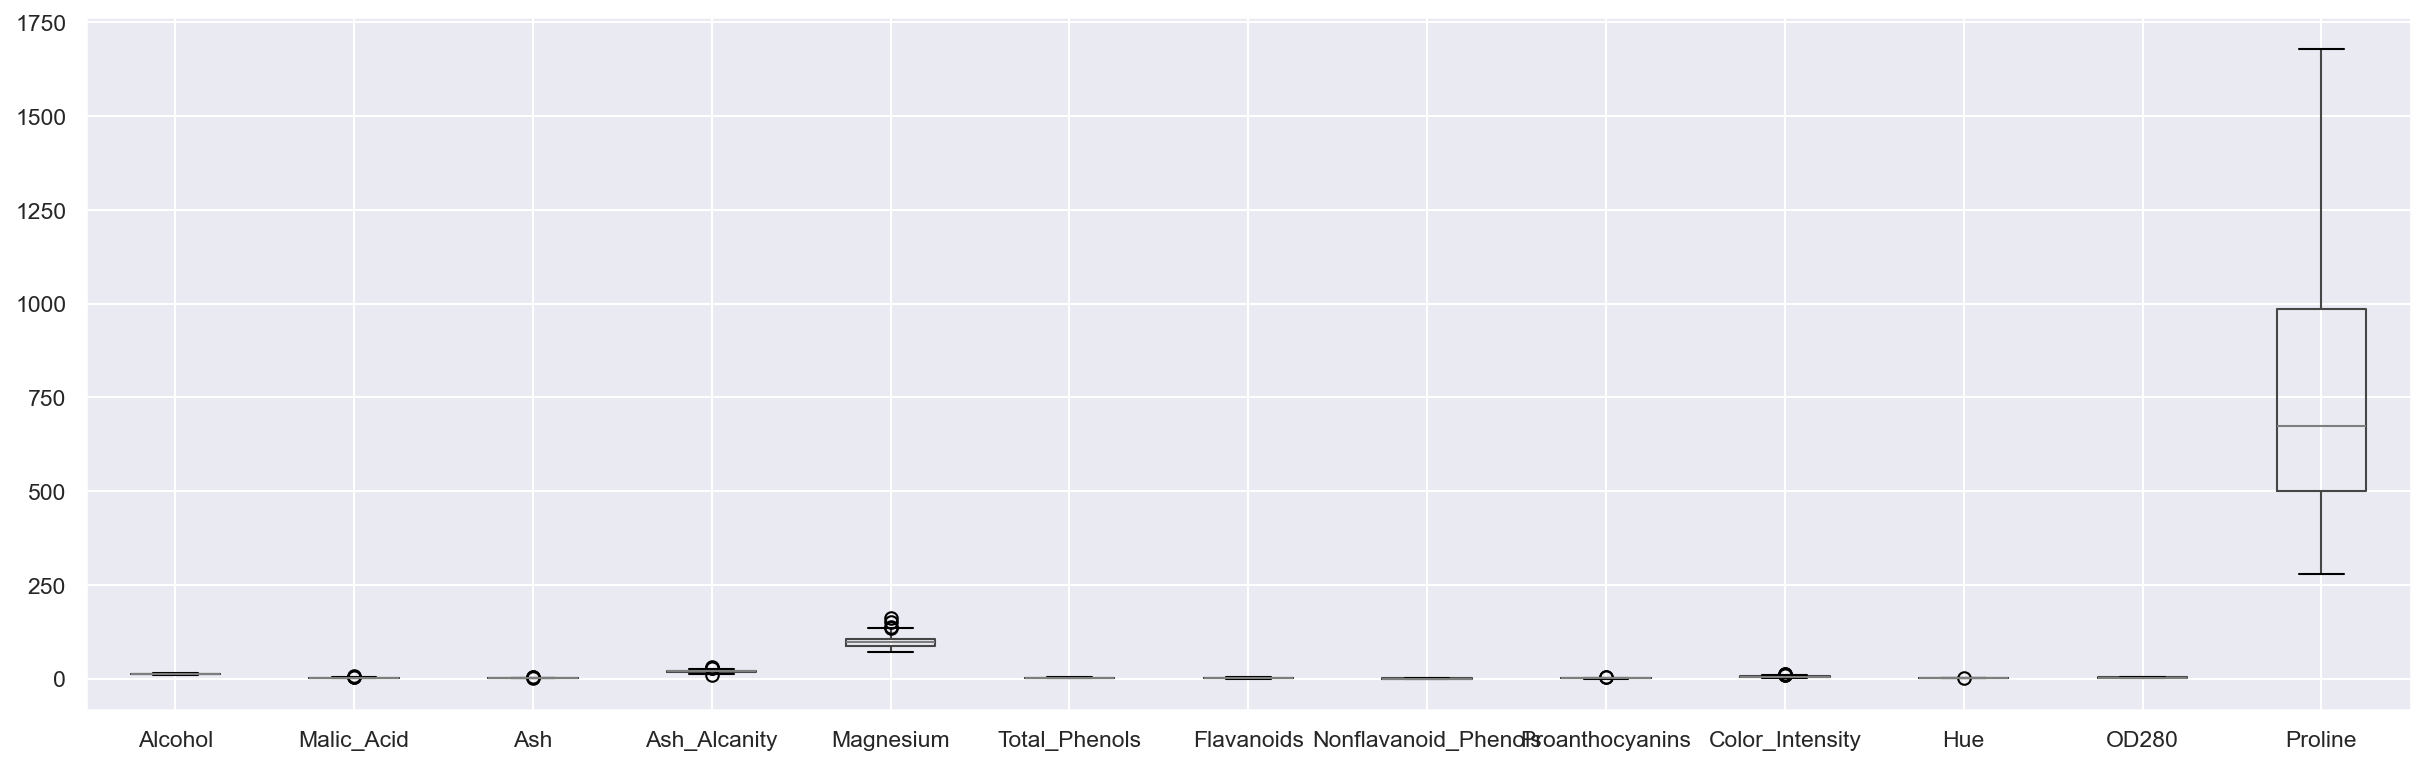

In [8]:
plt.figure(figsize=(20,6))
df.boxplot()
plt.show()

In [9]:
df.replace(['!','',' ','@','#','$','*','empty'], np.nan, inplace=True)

In [10]:
df.isna().sum()

Alcohol                 0
Malic_Acid              0
Ash                     0
Ash_Alcanity            0
Magnesium               0
Total_Phenols           0
Flavanoids              0
Nonflavanoid_Phenols    0
Proanthocyanins         0
Color_Intensity         0
Hue                     0
OD280                   0
Proline                 0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

### Scaling: Scaling is very important in clustering algorithms because clustering often depends on distance between data points.

In [12]:
sc=StandardScaler()
x=sc.fit_transform(df)
x

array([[ 1.51861254, -0.5622498 ,  0.23205254, ...,  0.36217728,
         1.84791957,  1.01300893],
       [ 0.24628963, -0.49941338, -0.82799632, ...,  0.40605066,
         1.1134493 ,  0.96524152],
       [ 0.19687903,  0.02123125,  1.10933436, ...,  0.31830389,
         0.78858745,  1.39514818],
       ...,
       [ 0.33275817,  1.74474449, -0.38935541, ..., -1.61212515,
        -1.48544548,  0.28057537],
       [ 0.20923168,  0.22769377,  0.01273209, ..., -1.56825176,
        -1.40069891,  0.29649784],
       [ 1.39508604,  1.58316512,  1.36520822, ..., -1.52437837,
        -1.42894777, -0.59516041]])

### Scatterplot by using scaled data

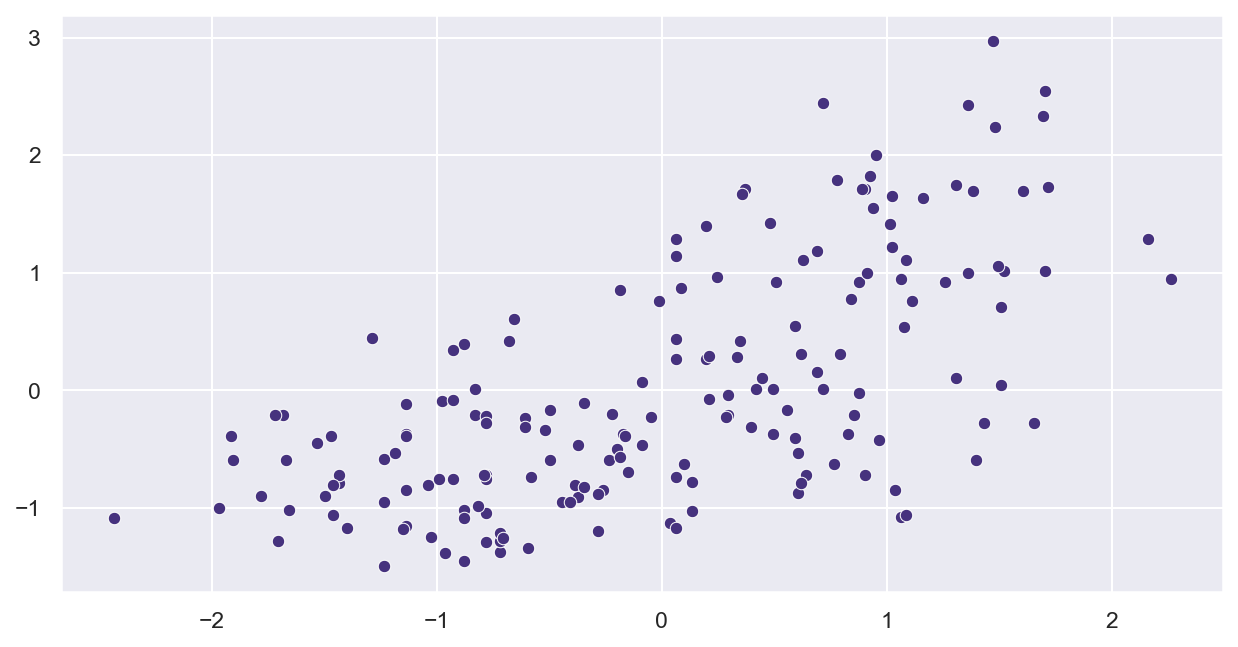

In [13]:
sns.scatterplot(x=x[:,0],y=x[:,-1])
plt.show()

### Model Building

In [14]:
km=KMeans()
yp=km.fit_predict(x)
yp

array([5, 5, 5, 5, 1, 5, 5, 1, 5, 5, 5, 5, 5, 5, 5, 1, 1, 1, 5, 1, 5, 1,
       5, 1, 1, 1, 1, 5, 1, 5, 1, 5, 1, 1, 1, 1, 1, 1, 6, 5, 5, 1, 5, 1,
       5, 1, 5, 5, 5, 5, 5, 5, 5, 1, 5, 5, 5, 1, 5, 6, 4, 4, 6, 3, 0, 3,
       6, 6, 4, 3, 7, 3, 6, 3, 3, 6, 6, 4, 3, 3, 6, 6, 0, 4, 3, 6, 0, 0,
       0, 0, 0, 0, 0, 6, 6, 3, 7, 6, 3, 3, 6, 6, 6, 6, 6, 0, 6, 0, 6, 3,
       3, 6, 0, 0, 0, 0, 6, 6, 4, 6, 3, 3, 0, 6, 3, 6, 6, 0, 0, 0, 7, 7,
       7, 7, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 7, 4, 4, 2, 2, 2, 7, 7, 7, 2,
       4, 2, 2, 2, 2, 2, 2, 4, 4, 4, 2, 2, 2, 2, 2, 2, 4, 2, 2, 2, 2, 2,
       2, 2], dtype=int32)

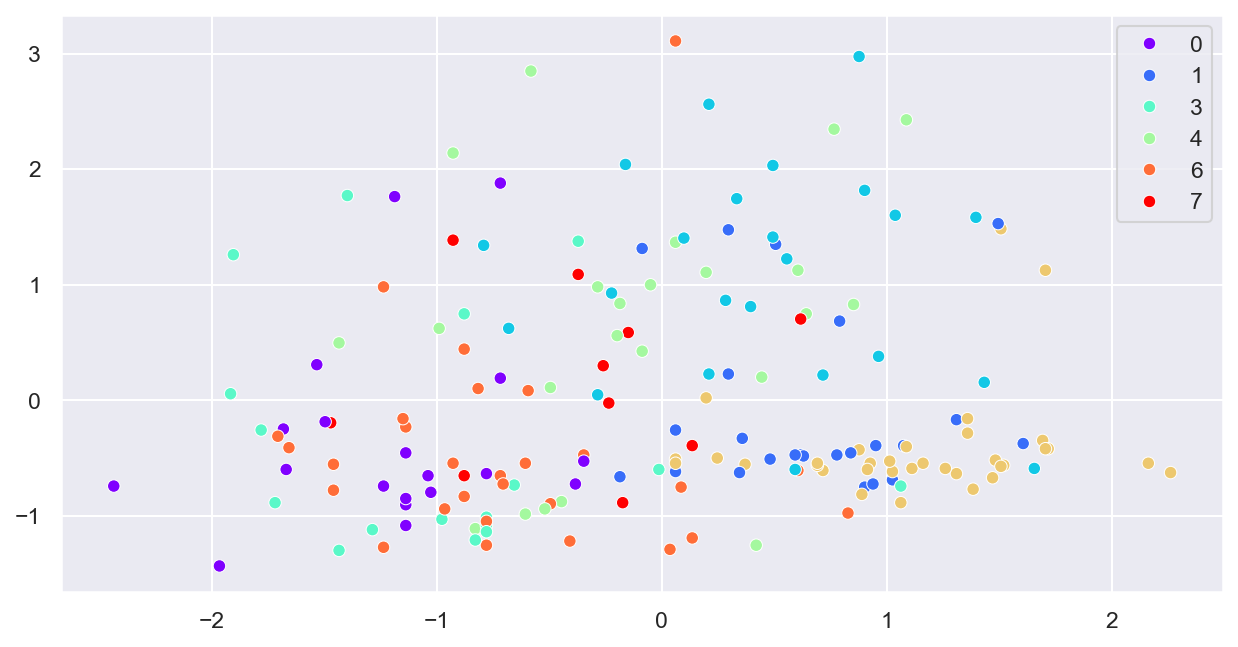

In [15]:
sns.scatterplot(x=x[:,0],y=x[:,1], hue=yp, palette='rainbow')
plt.show()

### Clusters centroid position

In [16]:
km.cluster_centers_

array([[-1.1976701 , -0.33830647,  0.31285481,  0.92924088, -0.87984665,
        -0.54623776, -0.1990033 ,  0.9519981 , -0.18139407, -1.02072191,
         0.62310847,  0.09203013, -0.84304811],
       [ 0.65289768, -0.09396886,  0.93265955, -0.23370495,  0.58862841,
         0.65944645,  0.7629113 , -0.28017475,  0.11377063, -0.04909953,
         0.53401471,  0.67029537,  0.95396311],
       [ 0.45628467,  1.07852232,  0.34965916,  0.72611904, -0.14365094,
        -0.81005414, -1.24156646,  0.92046755, -0.41293379,  1.7690971 ,
        -1.42518637, -1.33253319, -0.28294157],
       [-0.96644992, -0.34628261, -0.04102293,  0.33183179,  0.55094037,
         0.8523546 ,  0.73481008, -0.64534346,  1.30527373, -0.71571319,
         0.49637822,  0.59583055, -0.40315417],
       [-0.11140014,  0.65271775, -0.06673185,  0.10988201, -0.24133906,
        -0.96750063, -1.273868  ,  1.22175943, -1.23336623, -0.06744457,
        -0.63355786, -1.05925621, -0.46958059],
       [ 1.13168396, -0.418887

In [17]:
km.cluster_centers_[:,0] 

array([-1.1976701 ,  0.65289768,  0.45628467, -0.96644992, -0.11140014,
        1.13168396, -0.68501192, -0.37134286])

### Identify the centroid in scatterplot

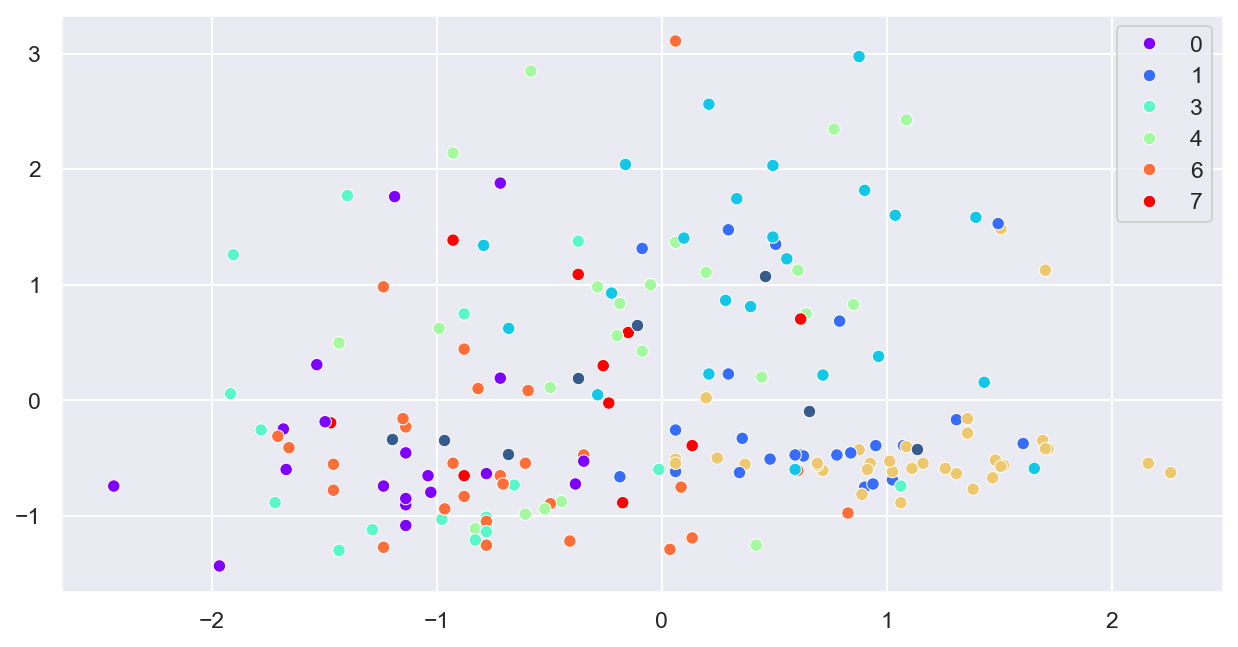

In [18]:
sns.scatterplot(x=x[:,0],y=x[:,1], hue=yp, palette='rainbow')
sns.scatterplot(x=km.cluster_centers_[:,0], y= km.cluster_centers_[:,1])
plt.show()

### Create Elbow Chart to find the best k value

In [19]:
km.inertia_

964.8310531888051

In [20]:
wcss=[]

for i in range(2,11):
    km=KMeans(n_clusters=i)
    km.fit_predict(x)
    wcss.append(km.inertia_)

In [21]:
wcss

[1659.9511977619795,
 1277.928488844642,
 1183.6696438612564,
 1137.3505199149465,
 1056.153791704046,
 1022.8415275216146,
 991.7483558320155,
 908.2765445693028,
 887.2379278953873]

Text(0.5, 1.0, 'Elbow Graph')

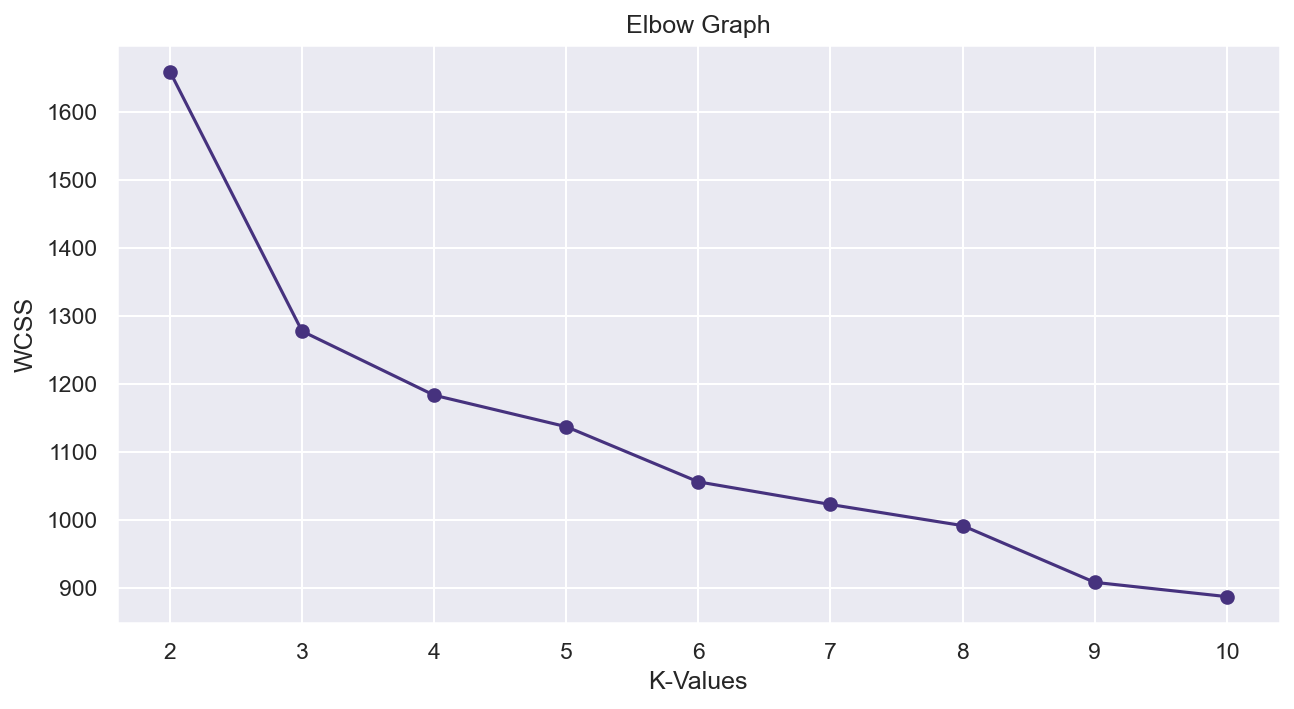

In [22]:
plt.plot(range(2,11),wcss, marker='o')
plt.xlabel('K-Values')
plt.ylabel('WCSS')
plt.title('Elbow Graph')

### Final Model after getting best k value

In [23]:
km=KMeans(n_clusters=3, random_state=0)
yp=km.fit_predict(x)
yp

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1], dtype=int32)

### It tells the position of centroid

In [24]:
km.cluster_centers_

array([[-0.92607185, -0.39404154, -0.49451676,  0.17060184, -0.49171185,
        -0.07598265,  0.02081257, -0.03353357,  0.0582655 , -0.90191402,
         0.46180361,  0.27076419, -0.75384618],
       [ 0.16490746,  0.87154706,  0.18689833,  0.52436746, -0.07547277,
        -0.97933029, -1.21524764,  0.72606354, -0.77970639,  0.94153874,
        -1.16478865, -1.29241163, -0.40708796],
       [ 0.83523208, -0.30380968,  0.36470604, -0.61019129,  0.5775868 ,
         0.88523736,  0.97781956, -0.56208965,  0.58028658,  0.17106348,
         0.47398365,  0.77924711,  1.12518529]])

### Analyse the cluster

In [25]:
yp

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1], dtype=int32)

In [26]:
df['Cluster']=yp
df.head()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline,Cluster
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,2
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,2
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,2
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,2
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,2


In [27]:
df.groupby('Cluster').mean()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
Cluster,,,,,,,,,,,,,
0,12.250923,1.897385,2.231231,20.063077,92.738462,2.247692,2.050000,0.357692,1.624154,2.973077,1.062708,2.803385,510.169231
1,13.134118,3.307255,2.417647,21.241176,98.666667,1.683922,0.818824,0.451961,1.145882,7.234706,0.691961,1.696667,619.058824
2,13.676774,1.997903,2.466290,17.462903,107.967742,2.847581,3.003226,0.292097,1.922097,5.453548,1.065484,3.163387,1100.225806


In [28]:
df['Cluster'].value_counts()

Cluster
0    65
2    62
1    51
Name: count, dtype: int64

### Evaluation of clustering model

In [29]:
from sklearn.metrics import silhouette_score 

In [30]:
silhouette_score(x,yp)

np.float64(0.2848589191898987)

### With PCA

In [32]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

pca = PCA(n_components=0.95)

x_pca = pca.fit_transform(x)

print("Original features:", x.shape[1])
print("PCA features:", x_pca.shape[1])

Original features: 13
PCA features: 10


In [38]:
km = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

labels = km.fit_predict(x_pca)

score = silhouette_score(x_pca, labels)

print("Silhouette Score:", score)

Silhouette Score: 0.29867482943692875


### conclusion:The Silhouette Score of 0.299 indicates that the K-Means clustering has moderate cluster separation.The clusters show some meaningful grouping, but there is also considerable overlap between them.
### After applying PCA, the dimensionality of the Wine dataset was reduced while retaining important information. K-Means was then able to identify groups of wines based on their chemical characteristics.
